# Week 9 - Exercise
### Notebook created by Jonathan Penava

For this exercise you are going to try to try and predict the carat range of a diamond based on some of its properties.  Start by importing the standard libraries and reading in the 'diamonds.csv' file. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report


Drop the 'Color', 'Clarity', and 'Unnamed: 0' Columns.

You will need to change the 'cut' values into int values.

Referencing what we did in week 5, create a new column for carat ranges with the values '0-1', '1-2','2-3','3-4','4-5','5-6'

Drop the column 'carat' after you have created the carat ranges column

Using K-Nearest Neighbours classify your carat ranges based on the other values in your dataframe.  Print out an accuracy score and a classification report for your algorithm.

Create a diagram of error rates for different values of K.  What value of K will give you a more accurate result?

In [2]:
diamonds = pd.read_csv("diamonds.csv")

In [3]:
diamonds.head()

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [4]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  53940 non-null  int64  
 1   carat       53940 non-null  float64
 2   cut         53940 non-null  str    
 3   color       53940 non-null  str    
 4   clarity     53940 non-null  str    
 5   depth       53940 non-null  float64
 6   table       53940 non-null  float64
 7   price       53940 non-null  int64  
 8   x           53940 non-null  float64
 9   y           53940 non-null  float64
 10  z           53940 non-null  float64
dtypes: float64(6), int64(2), str(3)
memory usage: 4.5 MB


In [5]:
diamonds.columns

Index(['Unnamed: 0', 'carat', 'cut', 'color', 'clarity', 'depth', 'table',
       'price', 'x', 'y', 'z'],
      dtype='str')

In [6]:
diamonds['cut'].unique()

<StringArray>
['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
Length: 5, dtype: str

In [7]:
diamonds.drop(['color', 'clarity', 'Unnamed: 0'], axis=1, inplace=True, errors='ignore')

In [8]:
diamonds.replace('Fair', 0, inplace=True)
diamonds.replace('Good', 1, inplace=True)
diamonds.replace('Very Good', 2, inplace=True)
diamonds.replace('Premium', 3, inplace=True)
diamonds.replace('Ideal', 4, inplace=True)

,carat,cut,depth,table,price,x,y,z
0,0.23,4,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,3,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...
53935,0.72,4,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,2,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,3,61.0,58.0,2757,6.15,6.12,3.74


In [9]:
diamonds['cut'].unique()

array([4, 3, 1, 2, 0], dtype=object)

In [10]:
bins = [0, 1, 2, 3, 4, 5, 6]
labels = ['0-1', '1-2', '2-3', '3-4', '4-5', '5-6']

diamonds['carat_range'] = pd.cut(diamonds['carat'], bins=bins, labels=labels, include_lowest=True)

In [11]:
diamonds[['carat', 'carat_range']].head(10)

,carat,carat_range
0,0.23,0-1
1,0.21,0-1
2,0.23,0-1
3,0.29,0-1
4,0.31,0-1
5,0.24,0-1
6,0.24,0-1
7,0.26,0-1
8,0.22,0-1
9,0.23,0-1


In [12]:
diamonds['carat_range'].isnull()

0        False
1        False
2        False
3        False
4        False
         ...  
53935    False
53936    False
53937    False
53938    False
53939    False
Name: carat_range, Length: 53940, dtype: bool

In [13]:
diamonds.drop('carat', axis=1, inplace=True)

In [14]:
diamonds.replace('0-1', 0, inplace=True)
diamonds.replace('1-2', 1, inplace=True)
diamonds.replace('2-3', 2, inplace=True)
diamonds.replace('3-4', 3, inplace=True)
diamonds.replace('4-5', 4, inplace=True)
diamonds.replace('5-6', 5, inplace=True)

TypeError: Cannot setitem on a Categorical with a new category (0), set the categories first

In [ ]:
diamonds['carat_range'].unique()

[0, 1, 2, 3, 4, 5]
Categories (6, int64): [0 < 1 < 2 < 3 < 4 < 5]

In [ ]:
X = diamonds.drop('carat_range', axis=1)
y = diamonds['carat_range']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [ ]:
print(knn.score(X_test, y_test))

0.9022370535162526


In [ ]:
predictions = knn.predict(X_test)
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     10989
           1       0.82      0.84      0.83      4652
           2       0.57      0.54      0.55       535
           3       0.00      0.00      0.00         4
           4       0.00      0.00      0.00         2

    accuracy                           0.90     16182
   macro avg       0.47      0.46      0.47     16182
weighted avg       0.90      0.90      0.90     16182



/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/miniconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
error_rate = []

for i in range(1, 40):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

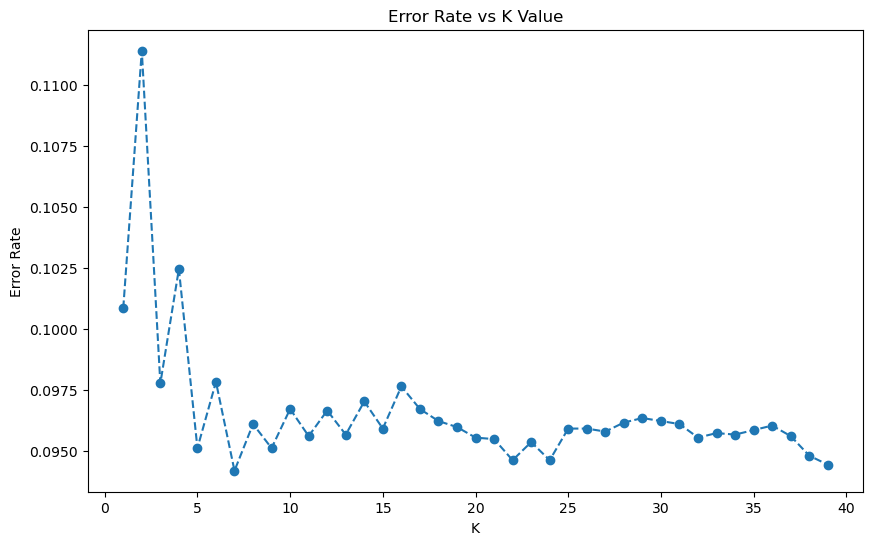

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40), error_rate, linestyle='dashed', marker='o')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.title('Error Rate vs K Value')
plt.show()

In [ ]:
best_k = error_rate.index(min(error_rate)) + 1
print("Best K:", best_k)

Best K: 7


The value of K that gives the most accurate result is 7. 
This is because it has the lowest error rate based on the error rate vs K graph.